In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Load the dataset
df = pd.read_csv('../data/supermarket_sales.csv')
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
# Make a copy to work with, so we don't disturb the original
model_df = df.copy()

# Columns we'll use to predict Customer type
features = ['Branch', 'City', 'Gender', 'Product line', 'Unit price', 
            'Quantity', 'Total', 'Payment', 'Rating']

# Encode text columns into numbers
label_encoders = {}
for col in ['Branch', 'City', 'Gender', 'Product line', 'Payment']:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    label_encoders[col] = le

# Encode our target: Customer type (Member/Normal)
target_encoder = LabelEncoder()
model_df['Customer type'] = target_encoder.fit_transform(model_df['Customer type'])

print(target_encoder.classes_)
model_df[features + ['Customer type']].head()

['Member' 'Normal']


,Branch,City,Gender,Product line,Unit price,Quantity,Total,Payment,Rating,Customer type
0,0,2,0,3,74.69,7,548.9715,2,9.1,0
1,2,1,0,0,15.28,5,80.2200,0,9.6,1
2,0,2,1,4,46.33,7,340.5255,1,7.4,1
3,0,2,1,3,58.22,8,489.0480,2,8.4,0
4,0,2,1,5,86.31,7,634.3785,2,5.3,1


In [4]:
X = model_df[features]
y = model_df['Customer type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 800
Testing rows: 200


In [5]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Check how well it did
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")
print(f"F1 Score: {f1:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

Accuracy: 52.00%
F1 Score: 0.515

              precision    recall  f1-score   support

      Member       0.50      0.55      0.52        97
      Normal       0.54      0.50      0.52       103

    accuracy                           0.52       200
   macro avg       0.52      0.52      0.52       200
weighted avg       0.52      0.52      0.52       200



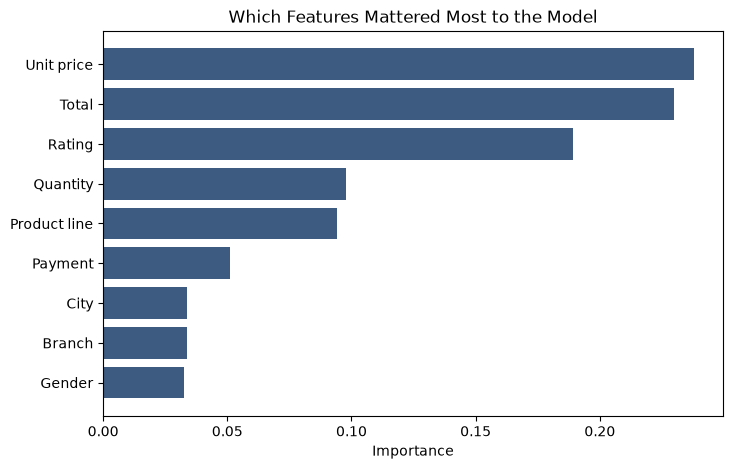

Unit price      0.237773
Total           0.230000
Rating          0.189263
Quantity        0.097752
Product line    0.094249
Payment         0.050932
City            0.033857
Branch          0.033762
Gender          0.032412
dtype: float64


In [6]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importances.index, importances.values, color='#3D5A80')
plt.title('Which Features Mattered Most to the Model')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

print(importances)

## Limitations and Biases

The model only reached 52% accuracy which is  barely better than a random guess, which tells me shopping 
behavior alone isn't a strong predictor of whether a customer is a Member or Normal customer in this dataset. A few reasons likely explain this.
To begin with, the dataset is relatively small at 1,000 rows, and only 800 of those were available for 
training. A larger dataset might reveal patterns that aren't visible here.
ALso, the features I used (branch, product line, spending, payment method) describe a single 
transaction, not a customer's full shopping history. Membership status is probably shaped by 
factors this dataset doesn't capture, like how often someone shops, how long they've been a 
customer, or whether they were specifically offered membership at checkout.
Futhermore, Unit price, Total, and Rating were the features the model relied on most, but these still 
weren't strong enough to produce confident predictions, suggesting spending amount alone doesn't 
clearly separate 'Members' from 'Normal' customers.
A possible bias worth noting is that this dataset only covers three months from one supermarket chain, 
so any patterns found here may not generalize to other stores, regions or time periods.